# Tarea 15/4/26 - ADC / Cuantización

Hacer FFT de la autocorrelacion

In [845]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

Vamos a simular el proceso de cuantización de una señal. Traemos el generador de senoidal ruidosa de la TS1 para generar nuestra señal muestreada de entrada:

In [846]:
rng = np.random.default_rng()

def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = rng.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

def pds_sen_ruidosa(nn = 1000, fs = 1000, freq = 1, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf"):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    x1 = dc + Amax * np.sin(2*np.pi * freq * tt + phase)

    if SNR_db != "inf" and (type(SNR_db) == float or type(SNR_db) == int):
        pot_senal = 10*np.log10((Amax**2) / 2)
        pot_ruido = pot_senal - SNR_db
        x2, tt = pds_awgn(nn, fs, potencia_W = 10**(pot_ruido/10))
        xx = x1 + x2
    else:
        xx = x1

    return xx, tt

def pds_obtener_potencia(x):
    return np.mean(x**2)


##### Grafico de la señal muestreada en el tiempo (sin cuantizar)

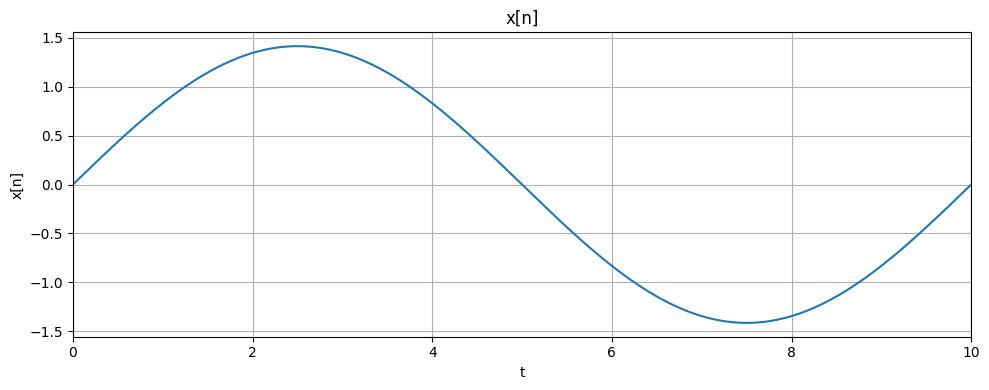

In [847]:
N = 5000
fs = 50
f0 = 10 * (fs/N)
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf")

figure, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.plot(tt, xx)
axs.set_xlabel('t')
axs.set_ylabel('x[n]')
axs.grid(True)
axs.set_title("x[n]")
axs.set_xlim(0, 1/f0)
plt.tight_layout()
plt.show()

El proceso de **cuantizacion** se encarga de mapear una señal continua a un número finito de niveles determinado por la resolución del ADC.

El **error de cuantización** es la diferencia entre el valor analógico original y su representación discreta, introducido por este proceso.

Definimos una resolución de 8 bits.

El rango del ADC debe cumplir $V_{FS} > 2 \cdot A_{MAX}$:

$$V_{FS} = 4 \text{ V} > 2\cdot\sqrt{2}\text{ V}$$


El paso de cuantización $q$ del ADC se define como el cociente entre el rango de entrada $V_{FS}$ y el número de niveles $2^B$, donde $B$ es la resolución en bits:

$$q = \frac{V_{FS}}{2^{B}}$$

In [848]:
BITS = 8
AMAX = np.sqrt(2)
VFS = 4
q = VFS/(2**BITS)

print(f"Paso de cuantizacion q = {q * 1000:.2f} mV para 8 bits de cuantización y VFS = {VFS} V")

Paso de cuantizacion q = 15.62 mV para 8 bits de cuantización y VFS = 4 V


Para simular la cuantización dividimos por q y redondeamos, y volvemos a multiplicar por q para volver a obtener tensiones. Tambien "clipeamos" la señal entre +$V_{FS} / 2$ y -$V_{FS} / 2$

Graficamos para 4, 8 y 16 bits de cuantizacion.

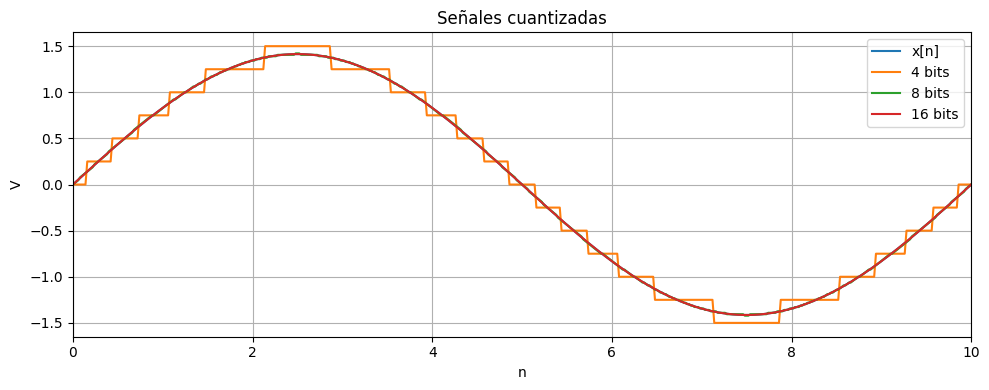

In [849]:
def pds_cuantizacion(xx, vfs, bits):
    xx_cuantizado = np.clip(xx, -vfs/2, vfs/2)
    q = vfs / (2 ** bits)
    xx_cuantizado = np.round(xx_cuantizado / q) * q
    return xx_cuantizado

xx_q1 = pds_cuantizacion(xx, VFS, 4)
xx_q2 = pds_cuantizacion(xx, VFS, 8)
xx_q3 = pds_cuantizacion(xx, VFS, 16)


figure, axs = plt.subplots(1, 1, figsize=(10, 4))

axs.plot(tt, xx, label = "x[n]")
axs.plot(tt, xx_q1, label = "4 bits")
axs.plot(tt, xx_q2, label = "8 bits")
axs.plot(tt, xx_q3, label = "16 bits")

axs.set_xlabel('n')
axs.set_ylabel('V')
axs.set_xlim(0, 1/f0)
axs.legend()
axs.grid(True)
axs.set_title("Señales cuantizadas")
plt.tight_layout()
plt.show()

A simple vista podemos vemos que para la señal original, 8 y 12 bits no notamos diferencias. Para 4 bits hay una diferencia notoria entre la señal original y la cuantizada.

El error de cuantización $e[n]$ se define como la diferencia entre la señal cuantizada $x_q[n]$ y la señal original $x[n]$:

$$e[n] = x_q[n] - x[n]$$

y se encuentra acotado por:

$$-\frac{q}{2} \leq e[n] < \frac{q}{2}$$

Podemos calcularlo y ver su distribución.
Vamos a hacer pruebas a 8 bits, que en principio no veiamos diferencias entre la señal original y la cuantizada.

Podemos calcular el SNR en dB teorico de la cuantizacion como: $$SNR_{dB} = 20\cdot log(F_C)+10\cdot log(\frac{3}{2})+20\cdot log(2)\cdot BITS_{ADC}$$

In [850]:
N = 1000
fs = 100
f0 = 10 * (fs/N)
BITS_ADC = 8

print(f"fs/N = {fs/N} Hz, f0 = {f0} Hz")

xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf")
xx_q = pds_cuantizacion(xx, VFS, BITS_ADC)
eq = xx_q - xx

SNRdb = 10 * np.log10(pds_obtener_potencia(xx) / (pds_obtener_potencia(eq)))
print(f"SNR de la señal cuantizada (medido): {SNRdb:.2f} dB")

print(f"SNR teorico = 20log(FC) + 10log(3/2) + 20log(2)*BITS = {20*np.log10((2*(np.sqrt(2)))/4) + 10*np.log10(3/2) + 20*np.log10(2)*BITS_ADC:.2f} dB")

fs/N = 0.1 Hz, f0 = 1.0 Hz
SNR de la señal cuantizada (medido): 46.79 dB
SNR teorico = 20log(FC) + 10log(3/2) + 20log(2)*BITS = 46.92 dB


Podemos ver claramente que la teoria se condice con la practica.

Maximo error: 0.50*q
Minimo error: -0.50*q


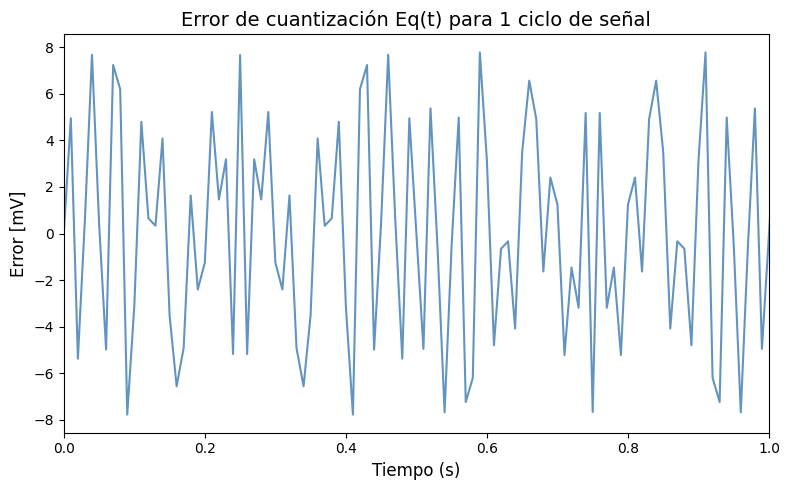

In [851]:
q = VFS/(2**BITS_ADC)

print(f"Maximo error: {(np.max(eq) / q):.2f}*q")
print(f"Minimo error: {(np.min(eq) / q):.2f}*q")

plt.figure(figsize=(8, 5))
plt.plot(tt, eq*1000, color='steelblue', alpha=0.85)

plt.title('Error de cuantización Eq(t) para 1 ciclo de señal', fontsize=14)
plt.xlabel('Tiempo (s)', fontsize=12)
plt.xlim(0, 1/f0)
plt.ylabel('Error [mV]', fontsize=12)
plt.tight_layout()
plt.show()

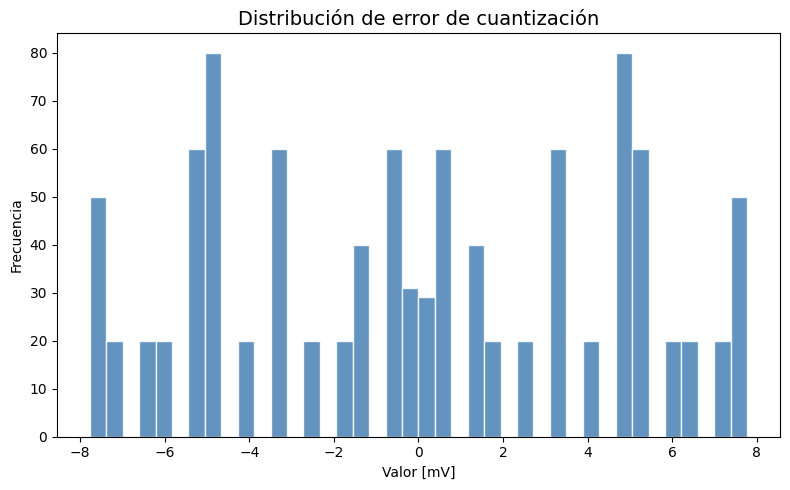

In [852]:
plt.figure(figsize=(8, 5))
plt.hist(eq*1000, bins=40, color='steelblue', edgecolor='white', alpha=0.85)

plt.title('Distribución de error de cuantización', fontsize=14)
plt.xlabel('Valor [mV]')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Vemos que la distribución no es una distribución uniforme como se esperaría. Para que el error de cuantización tenga distribución uniforme la señal de entrada debe ser una señal completamente incorrelacionada con si misma (sin autocorrelacion), obviamente no es nuestro caso con nuestra señal senoidal sin ruido.

Podemos comprobarlo:

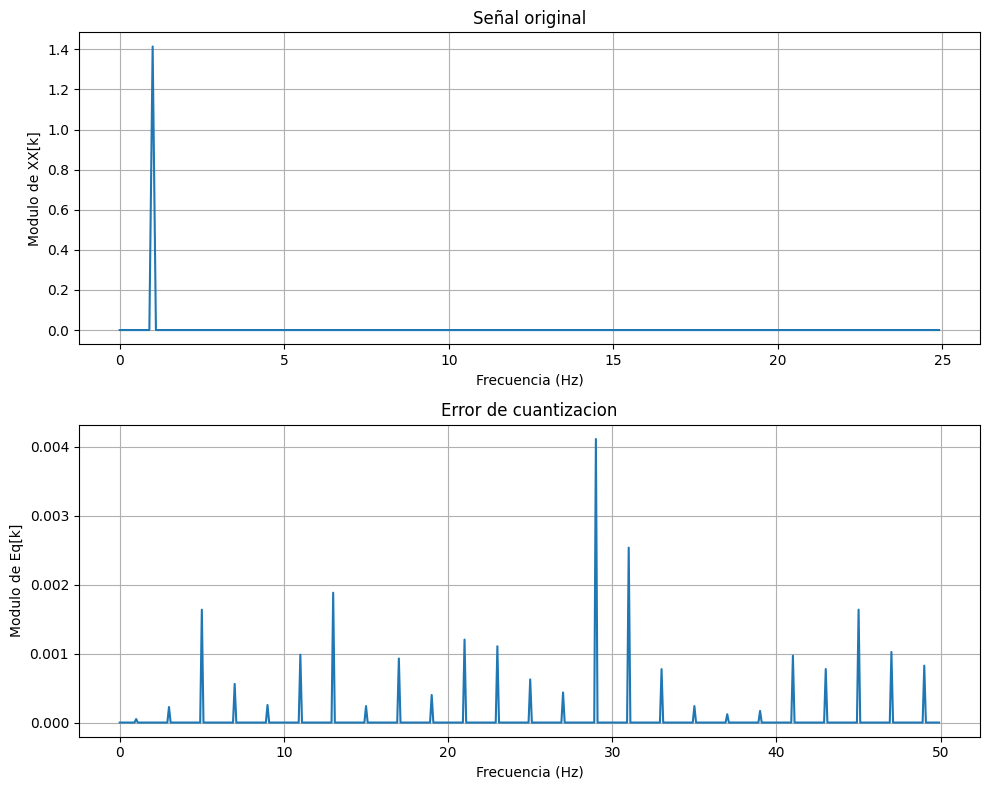

In [853]:
eq_fft = np.fft.fft(eq)
eq_fft = eq_fft[:len(eq_fft)//2]
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(np.arange(len(eq_fft)) * fs / N, 2*np.abs(eq_fft)/N)
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('Modulo de Eq[k]')
axs[1].grid(True)
axs[1].set_title("Error de cuantizacion")

xx_fft = np.fft.fft(xx)[:len(eq)//2]
xx_fft = xx_fft[:len(xx_fft)//2]
axs[0].plot(np.arange(len(xx_fft)) * fs / N, 2*np.abs(xx_fft)/N)
axs[0].set_xlabel('Frecuencia (Hz)')
axs[0].set_ylabel('Modulo de XX[k]')
axs[0].grid(True)
axs[0].set_title("Señal original")


plt.tight_layout()
plt.show()


Podemos ver que el error de cuantizacion esta tiene deltas como componentes espectrales, indicando que tiene algun tipo de estructura temporal. Podemos calcular las correlaciones de las señales:

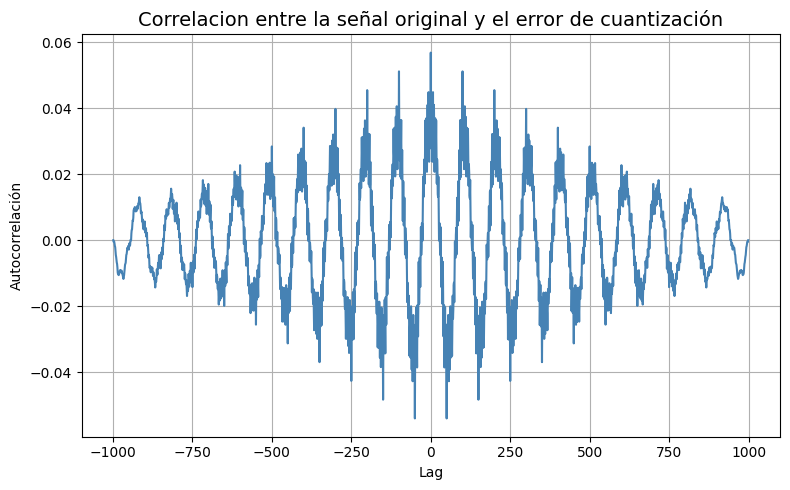

In [854]:
corr = signal.correlate(xx_q, eq, mode='full', method='auto')
lags = signal.correlation_lags(len(xx_q), len(eq), mode='full')

plt.figure(figsize=(8, 5))
plt.plot(lags, corr, color='steelblue')
plt.title('Correlacion entre la señal original y el error de cuantización', fontsize=14)
plt.xlabel('Lag')
plt.ylabel('Autocorrelación')
plt.grid(True)
plt.tight_layout()
plt.show()

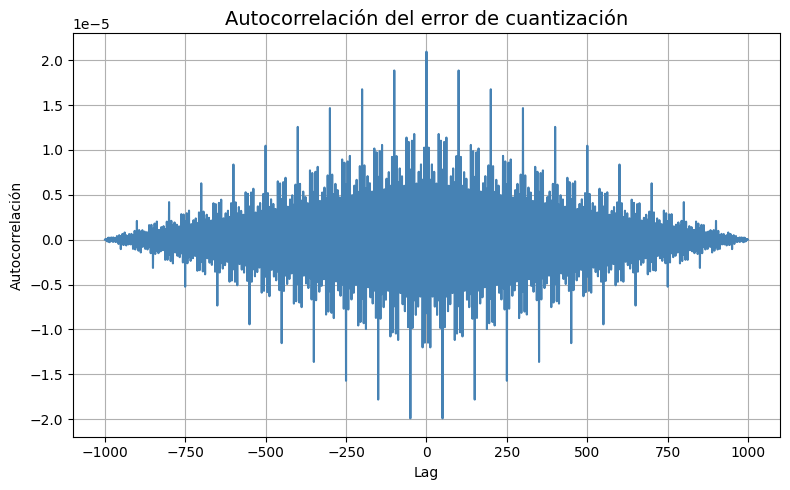

Valor de la autocorrelacion en lag 0: 2.095277657387771e-05 = -46.7875841800494 dB


In [855]:
eq_autocorr = signal.correlate(eq, eq, mode='full', method='auto') / N
lags = signal.correlation_lags(len(eq), len(eq), mode='full')

plt.figure(figsize=(8, 5))
plt.plot(lags, eq_autocorr, color='steelblue')
plt.title('Autocorrelación del error de cuantización', fontsize=14)
plt.xlabel('Lag')
plt.ylabel('Autocorrelación')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Valor de la autocorrelacion en lag 0: {eq_autocorr[len(eq_autocorr)//2]} = {10 * np.log10(eq_autocorr[len(eq_autocorr)//2])} dB")

Acompañanando lo que se veia en el espectro, en la autocorrelacion del ruido vemos algo distinto a un solo delta en el lag 0, indicando que el ruido tiene estructura temporal.

Podemos ver el espectro de estas dos correlaciones:

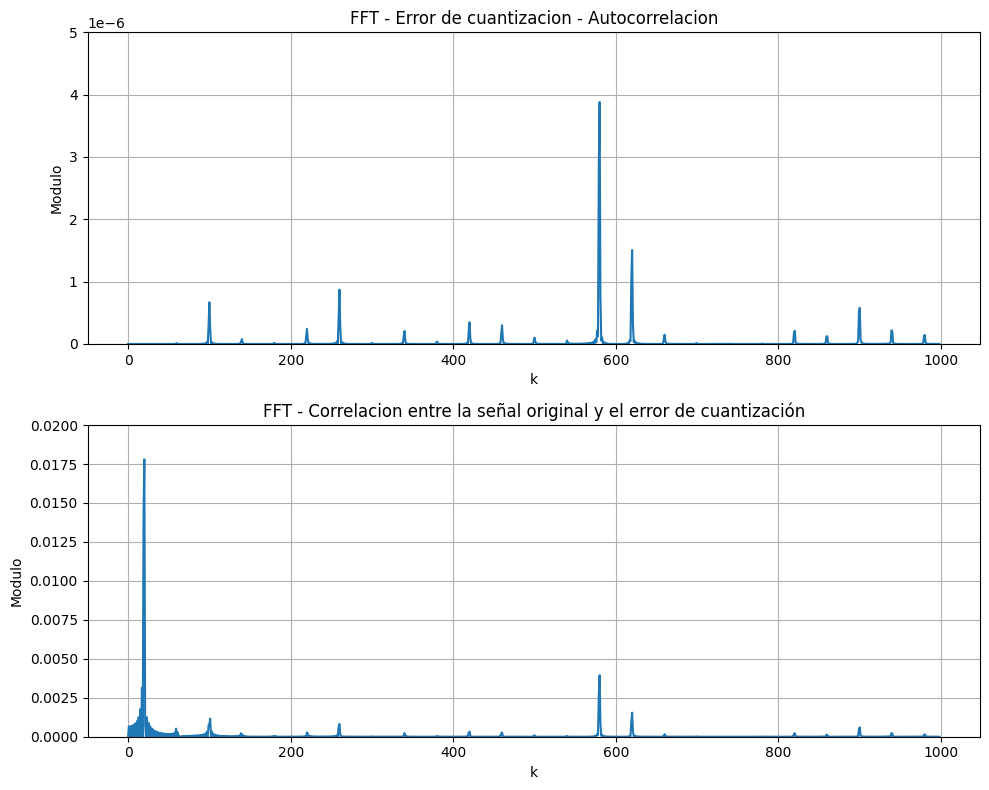

In [856]:
corr_fft = np.fft.fft(corr)
corr_fft = corr_fft[:len(corr_fft)//2]
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(2*np.abs(corr_fft)/len(corr))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Modulo')
axs[1].grid(True)
axs[1].set_title("FFT - Correlacion entre la señal original y el error de cuantización")
axs[1].set_ylim(0, 0.02)

eq_autocorr_fft = np.fft.fft(eq_autocorr)
eq_autocorr_fft = eq_autocorr_fft[:len(eq_autocorr_fft)//2]
axs[0].plot(2*np.abs(eq_autocorr_fft)/len(eq_autocorr))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Modulo')
axs[0].grid(True)
axs[0].set_title("FFT - Error de cuantizacion - Autocorrelacion")
axs[0].set_ylim(0, 5e-6)

plt.tight_layout()
plt.show()

### Señal ruidosa

Ahora hacemos el experimento para una señal ruidosa:

In [857]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = 30)
xx_q = pds_cuantizacion(xx, VFS, BITS_ADC)
eq = xx_q - xx

SNRdb = 10 * np.log10(1 / abs(1-pds_obtener_potencia(xx_q)))
print(f"SNR de la señal cuantizada: {SNRdb:.2f} dB")

SNR de la señal cuantizada: 26.89 dB


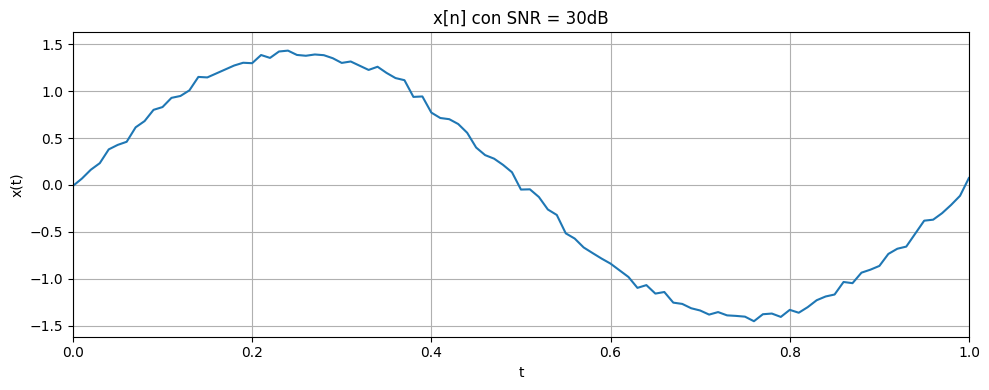

In [858]:
figure, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.plot(tt, xx)
axs.set_xlabel('t')
axs.set_ylabel('x(t)')
axs.grid(True)
axs.set_title("x[n] con SNR = 30dB")
axs.set_xlim(0, 1/f0)
plt.tight_layout()
plt.show()

Como el ruido de la señal es mayor al de la cuantificacion, el que predomina es el AWGN.

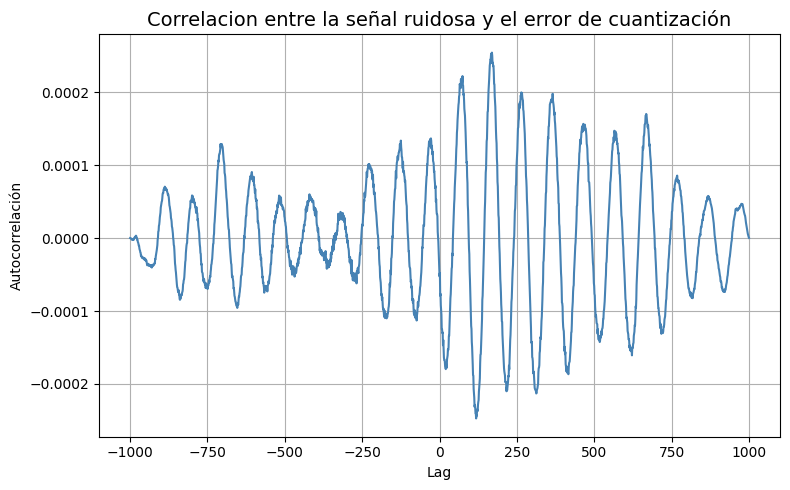

In [859]:
corr = signal.correlate(xx, eq, mode='full', method='auto') / N
lags = signal.correlation_lags(len(xx), len(eq), mode='full')

plt.figure(figsize=(8, 5))
plt.plot(lags, corr, color='steelblue')
plt.title('Correlacion entre la señal ruidosa y el error de cuantización', fontsize=14)
plt.xlabel('Lag')
plt.ylabel('Autocorrelación')
plt.grid(True)
plt.tight_layout()
plt.show()

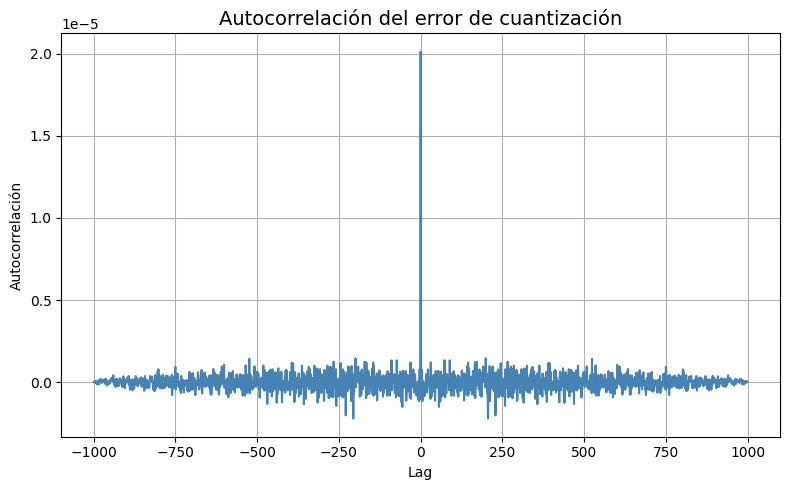

Valor de la correlacion en lag 0: 2.0123559358920253e-05 = -46.96295200891339 dB


In [860]:
eq_autocorr = signal.correlate(eq, eq, mode='full', method='auto') / N
lags = signal.correlation_lags(len(eq), len(eq), mode='full')

plt.figure(figsize=(8, 5))
plt.plot(lags, eq_autocorr, color='steelblue')
plt.title('Autocorrelación del error de cuantización', fontsize=14)
plt.xlabel('Lag')
plt.ylabel('Autocorrelación')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Valor de la correlacion en lag 0: {eq_autocorr[len(eq_autocorr)//2]} = {10 * np.log10(eq_autocorr[len(eq_autocorr)//2])} dB")

Volvemos a graficar los espectros de las correlaciones, pero manteniendo los ejes Y como en el grafico anterior de espectros de correlaciones, para poder comparar valores maximos.

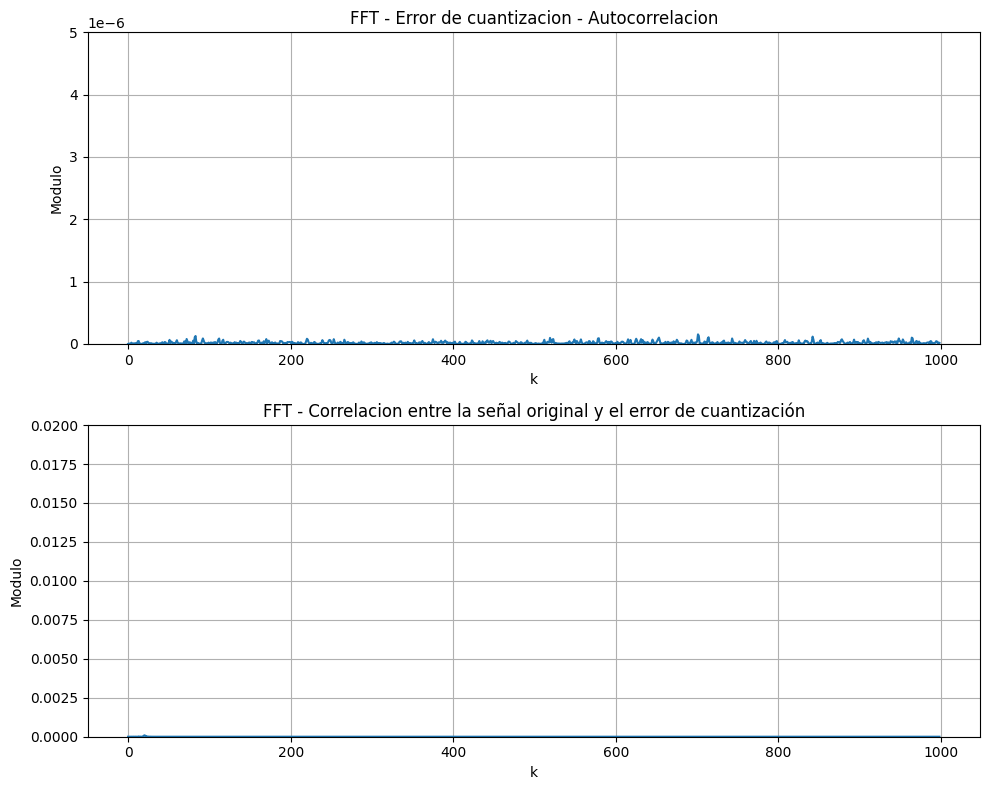

In [861]:
corr_fft = np.fft.fft(corr)
corr_fft = corr_fft[:len(corr_fft)//2]
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(2*np.abs(corr_fft)/len(corr))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Modulo')
axs[1].grid(True)
axs[1].set_title("FFT - Correlacion entre la señal original y el error de cuantización")
axs[1].set_ylim(0, 0.02)

eq_autocorr_fft = np.fft.fft(eq_autocorr)
eq_autocorr_fft = eq_autocorr_fft[:len(eq_autocorr_fft)//2]
axs[0].plot(2*np.abs(eq_autocorr_fft)/len(eq_autocorr))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Modulo')
axs[0].grid(True)
axs[0].set_title("FFT - Error de cuantizacion - Autocorrelacion")
axs[0].set_ylim(0, 5e-6)

plt.tight_layout()
plt.show()

Claramente vemos que el ruido AWGN sumado a la señal de entrada "mató" todo el espectro de la correlación y la autocorrelación.

Ahora vamos a ver que la distribucion del error de cuantizacion se asemeja mucho mas a una distribucion normal (como lo planteamos en la teoria):

Maximo error: 0.50*q
Minimo error: -0.50*q


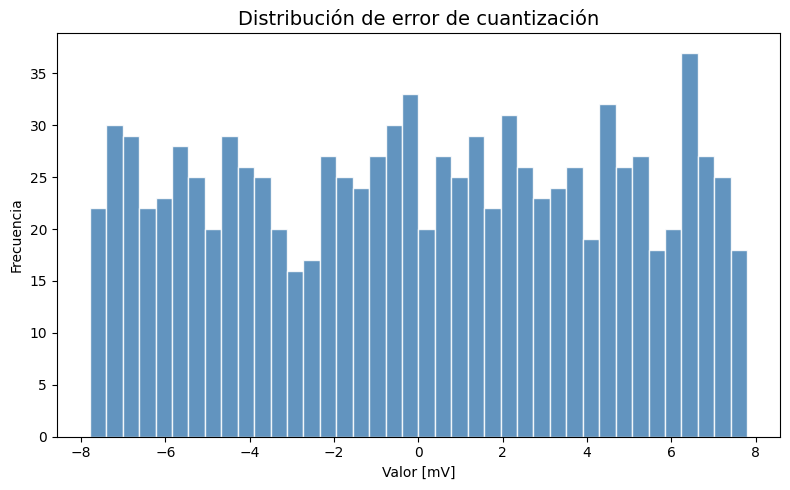

In [862]:
print(f"Maximo error: {(np.max(eq) / q):.2f}*q")
print(f"Minimo error: {(np.min(eq) / q):.2f}*q")

plt.figure(figsize=(8, 5))
plt.hist(eq*1000, bins=40, color='steelblue', edgecolor='white', alpha=0.85)

plt.title('Distribución de error de cuantización', fontsize=14)
plt.xlabel('Valor [mV]')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Ahora podemos graficar el espectro de la señal original, la señal de error y la señal cuantizada. Lo que esperamos ver, segun los resulados de arriba, es que deberia predominar el error AWGN de entrada porque es mayor al error de cuantizacion.

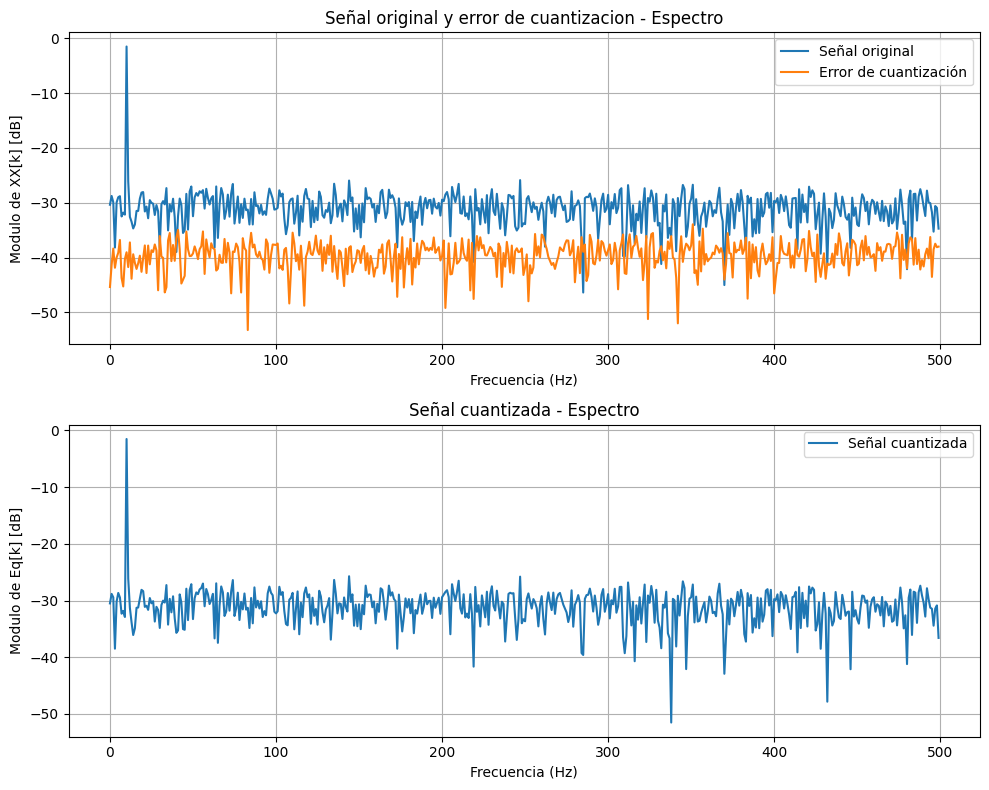

In [863]:
eq_fft = np.fft.fft(eq)
eq_fft = eq_fft[:len(eq_fft)//2]
xx_fft = np.fft.fft(xx)
xx_fft = xx_fft[:len(xx_fft)//2]
xx_q_fft = np.fft.fft(xx_q)
xx_q_fft = xx_q_fft[:len(xx_q_fft)//2]

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(10*np.log10(np.abs(xx_q_fft)  / N), label = "Señal cuantizada")
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('Modulo de Eq[k] [dB]')
axs[1].grid(True)
axs[1].set_title("Señal cuantizada - Espectro")
axs[1].legend()


axs[0].plot(10*np.log10(np.abs(xx_fft)  / N), label = "Señal original")
axs[0].plot(10*np.log10(np.abs(eq_fft) / N), label = "Error de cuantización")
axs[0].set_xlabel('Frecuencia (Hz)')
axs[0].set_ylabel('Modulo de XX[k] [dB]')
axs[0].grid(True)
axs[0].set_title("Señal original y error de cuantizacion - Espectro")
axs[0].legend()

plt.tight_layout()
plt.show()

##### Pruebas y graficos para otros SNR

Ahora vamos a probar SNR de 60dB, 46dB (mismo SNR que potencia de ruido), 15dB y 0dB

Con un SNR de 60dB, el ruido que deberia predominar es el ruido de cuantizacion que como ya vimos estaba en 46 dB.

In [894]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = 60)
xx_q = pds_cuantizacion(xx, VFS, BITS_ADC)
eq = xx_q - xx

SNRdb = 10 * np.log10(1 / abs(1-pds_obtener_potencia(xx_q)))
print(f"SNR de la señal cuantizada: {SNRdb:.2f} dB")

SNR de la señal cuantizada: 43.27 dB


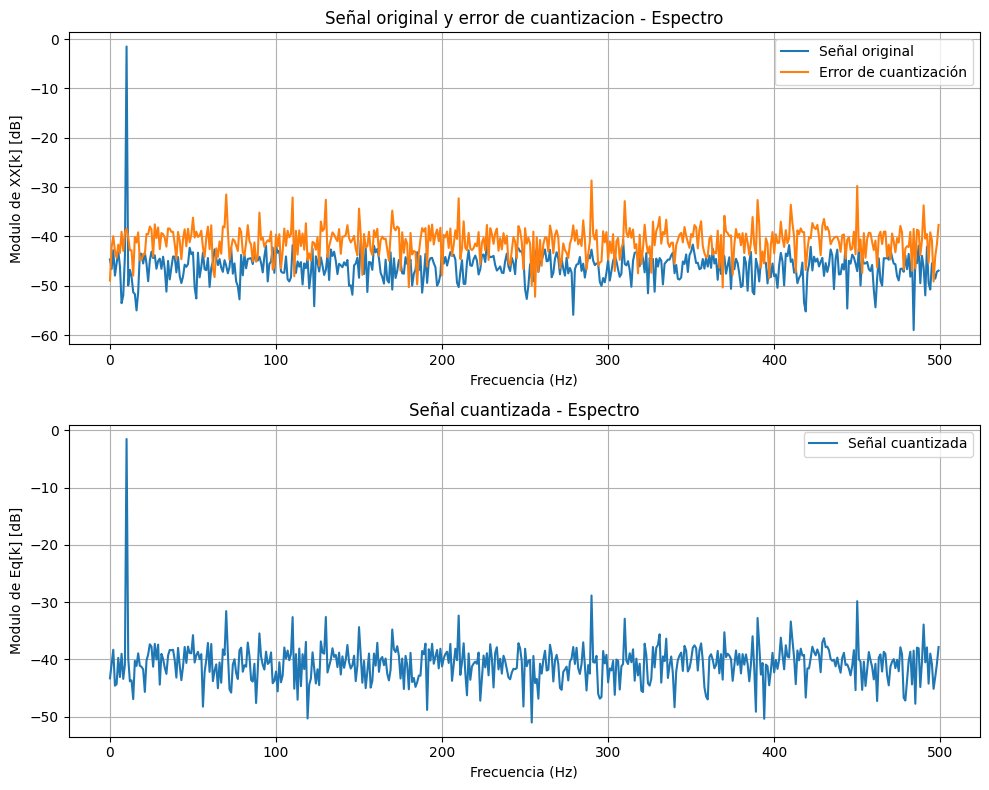

In [895]:
eq_fft = np.fft.fft(eq)
eq_fft = eq_fft[:len(eq_fft)//2]
xx_fft = np.fft.fft(xx)
xx_fft = xx_fft[:len(xx_fft)//2]
xx_q_fft = np.fft.fft(xx_q)
xx_q_fft = xx_q_fft[:len(xx_q_fft)//2]

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(10*np.log10(np.abs(xx_q_fft)  / N), label = "Señal cuantizada")
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('Modulo de Eq[k] [dB]')
axs[1].grid(True)
axs[1].set_title("Señal cuantizada - Espectro")
axs[1].legend()


axs[0].plot(10*np.log10(np.abs(xx_fft)  / N), label = "Señal original")
axs[0].plot(10*np.log10(np.abs(eq_fft) / N), label = "Error de cuantización")
axs[0].set_xlabel('Frecuencia (Hz)')
axs[0].set_ylabel('Modulo de XX[k] [dB]')
axs[0].grid(True)
axs[0].set_title("Señal original y error de cuantizacion - Espectro")
axs[0].legend()

plt.tight_layout()
plt.show()

El caso de SNR de 46 dB es nuestro caso ideal, donde tenemos la mayor SNR con el menor costo, ya que la calidad de filtrado analogico acompaña lo digital.

In [896]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = 46)
xx_q = pds_cuantizacion(xx, VFS, BITS_ADC)
eq = xx_q - xx

SNRdb = 10 * np.log10(1 / abs(1-pds_obtener_potencia(xx_q)))
print(f"SNR de la señal cuantizada: {SNRdb:.2f} dB")

SNR de la señal cuantizada: 44.98 dB


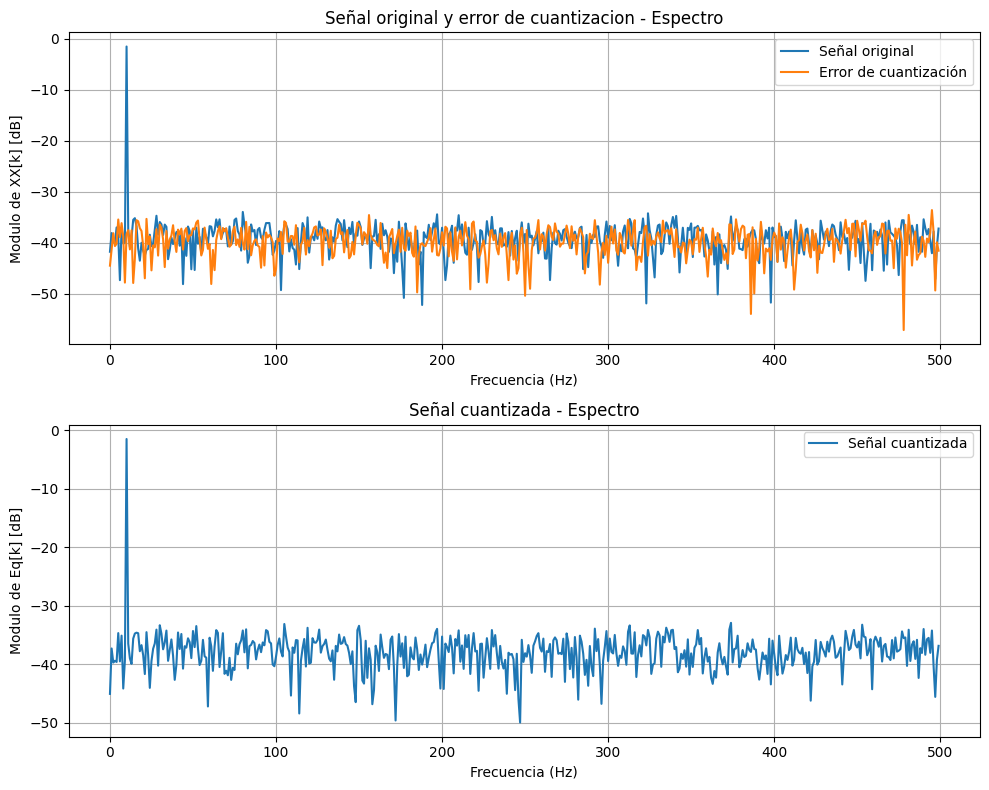

In [897]:
eq_fft = np.fft.fft(eq)
eq_fft = eq_fft[:len(eq_fft)//2]
xx_fft = np.fft.fft(xx)
xx_fft = xx_fft[:len(xx_fft)//2]
xx_q_fft = np.fft.fft(xx_q)
xx_q_fft = xx_q_fft[:len(xx_q_fft)//2]

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(10*np.log10(np.abs(xx_q_fft)  / N), label = "Señal cuantizada")
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('Modulo de Eq[k] [dB]')
axs[1].grid(True)
axs[1].set_title("Señal cuantizada - Espectro")
axs[1].legend()


axs[0].plot(10*np.log10(np.abs(xx_fft)  / N), label = "Señal original")
axs[0].plot(10*np.log10(np.abs(eq_fft) / N), label = "Error de cuantización")
axs[0].set_xlabel('Frecuencia (Hz)')
axs[0].set_ylabel('Modulo de XX[k] [dB]')
axs[0].grid(True)
axs[0].set_title("Señal original y error de cuantizacion - Espectro")
axs[0].legend()

plt.tight_layout()
plt.show()

Con un SNR de 15 dB, el error que predomina es el de la señal de entrada:

In [902]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = 15)
xx_q = pds_cuantizacion(xx, VFS, BITS_ADC)
eq = xx_q - xx

SNRdb = 10 * np.log10(1 / abs(1-pds_obtener_potencia(xx_q)))
print(f"SNR de la señal cuantizada: {SNRdb:.2f} dB")

SNR de la señal cuantizada: 14.87 dB


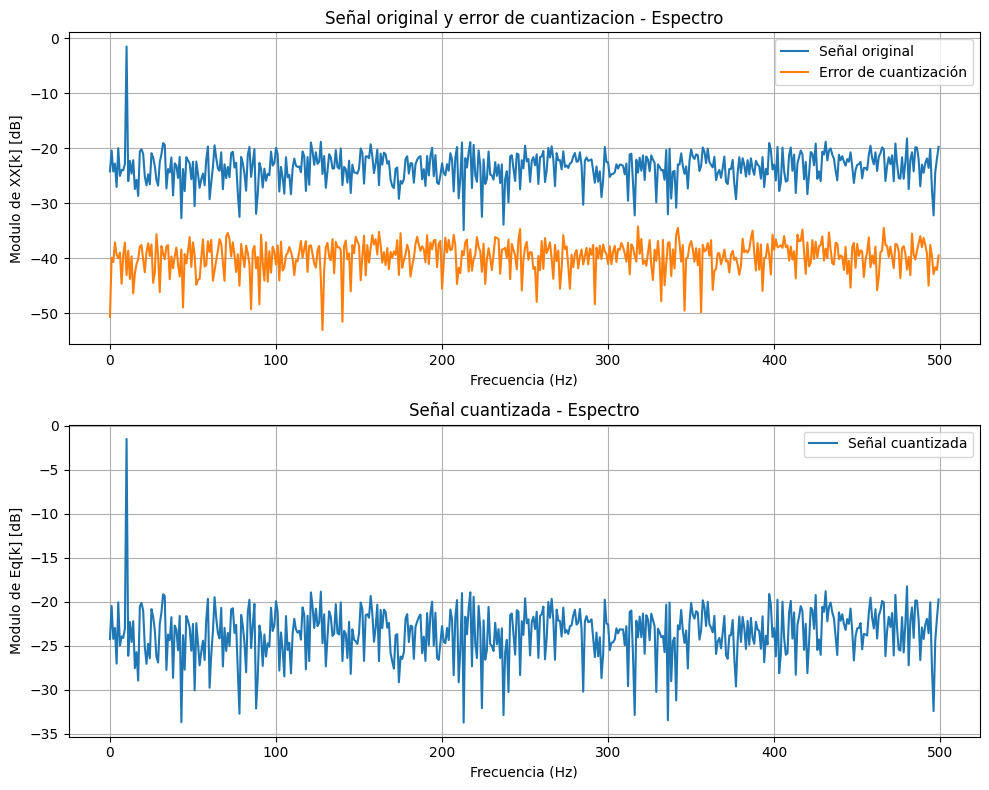

In [903]:
eq_fft = np.fft.fft(eq)
eq_fft = eq_fft[:len(eq_fft)//2]
xx_fft = np.fft.fft(xx)
xx_fft = xx_fft[:len(xx_fft)//2]
xx_q_fft = np.fft.fft(xx_q)
xx_q_fft = xx_q_fft[:len(xx_q_fft)//2]

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(10*np.log10(np.abs(xx_q_fft)  / N), label = "Señal cuantizada")
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('Modulo de Eq[k] [dB]')
axs[1].grid(True)
axs[1].set_title("Señal cuantizada - Espectro")
axs[1].legend()


axs[0].plot(10*np.log10(np.abs(xx_fft)  / N), label = "Señal original")
axs[0].plot(10*np.log10(np.abs(eq_fft) / N), label = "Error de cuantización")
axs[0].set_xlabel('Frecuencia (Hz)')
axs[0].set_ylabel('Modulo de XX[k] [dB]')
axs[0].grid(True)
axs[0].set_title("Señal original y error de cuantizacion - Espectro")
axs[0].legend()

plt.tight_layout()
plt.show()

Con un SNR de 0 dB, tambien el error que predomina es el de la señal. Como nuestra señal (ideal) tiene una potencia de 1W, tendremos la misma potencia de señal que de ruido a la entrada:

In [955]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = 0)
xx_q = pds_cuantizacion(xx, VFS, BITS_ADC)
eq = xx_q - xx

SNRdb = 10 * np.log10(1 / abs(1-pds_obtener_potencia(xx_q)))
print(f"SNR de la señal cuantizada: {SNRdb:.2f} dB")

SNR de la señal cuantizada: 1.91 dB


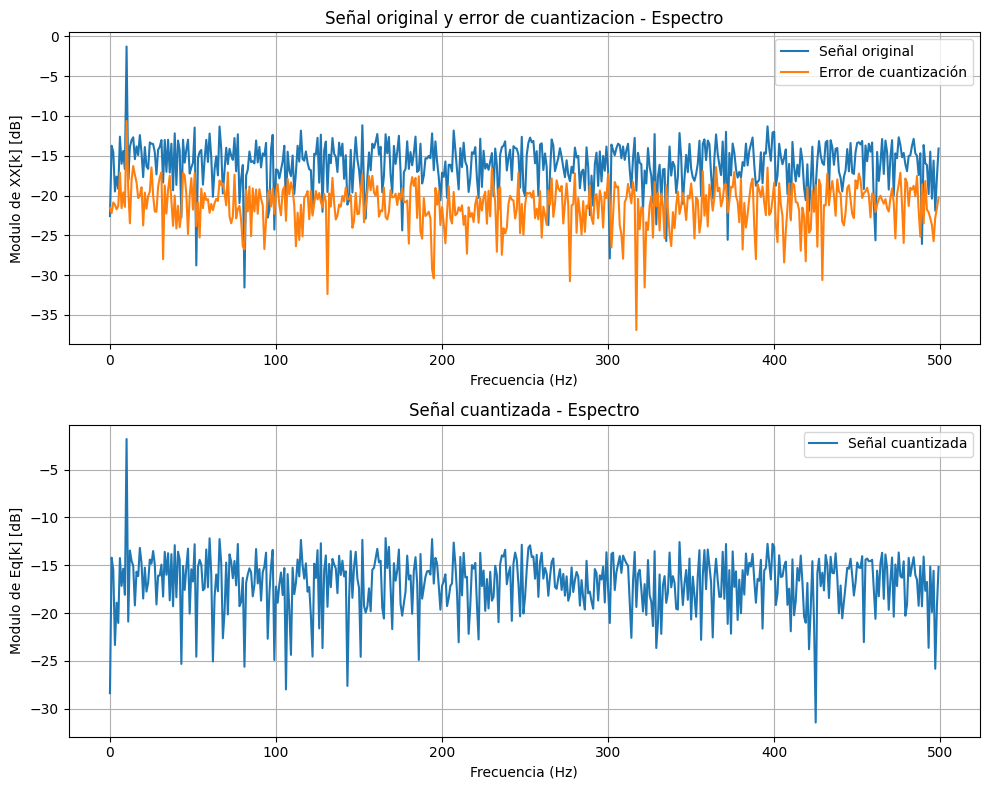

In [956]:
eq_fft = np.fft.fft(eq)
eq_fft = eq_fft[:len(eq_fft)//2]
xx_fft = np.fft.fft(xx)
xx_fft = xx_fft[:len(xx_fft)//2]
xx_q_fft = np.fft.fft(xx_q)
xx_q_fft = xx_q_fft[:len(xx_q_fft)//2]

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(10*np.log10(np.abs(xx_q_fft)  / N), label = "Señal cuantizada")
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('Modulo de Eq[k] [dB]')
axs[1].grid(True)
axs[1].set_title("Señal cuantizada - Espectro")
axs[1].legend()


axs[0].plot(10*np.log10(np.abs(xx_fft)  / N), label = "Señal original")
axs[0].plot(10*np.log10(np.abs(eq_fft) / N), label = "Error de cuantización")
axs[0].set_xlabel('Frecuencia (Hz)')
axs[0].set_ylabel('Modulo de XX[k] [dB]')
axs[0].grid(True)
axs[0].set_title("Señal original y error de cuantizacion - Espectro")
axs[0].legend()

plt.tight_layout()
plt.show()

Vemos que en el caso de 0dB, tambien sube considerablemente la potencia de señal de ruido.

In [958]:
print(f"Potencia de ruido: {10 * np.log10(pds_obtener_potencia(eq)):.6f} dB")

Potencia de ruido: -9.505408 dB
